In [ ]:
# ! pip install pytorchvideo transformers evaluate -q
# ! pip install pytorchvideo torchvision==0.12.0
# ! pip install evaluate

In [2]:
# pip install opencv-python


In [ ]:
# ! pip install --upgrade torch

In [1]:
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
#model_ckpt = "google/vivit-b-16x2-kinetics400"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"

batch_size = 4 # batch size for training and evaluation
from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)

/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")


VideoMAEConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "decoder_hidden_size": 384,
  "decoder_intermediate_size": 1536,
  "decoder_num_attention_heads": 6,
  "decoder_num_hidden_layers": 4,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "videomae",
  "norm_pix_loss": true,
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 16,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.1",
  "tubelet_size": 2,
  "use_mean_pooling": true
}



In [ ]:
# model_ckpt="facebook/timesformer-base-finetuned-k400"
# #model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
# #model_ckpt = "google/vivit-b-16x2-kinetics400"
# batch_size = 4 # batch size for training and evaluation
# from transformers import TimesformerConfig, TimesformerModel

# # Initializing a TimeSformer timesformer-base style configuration
# configuration = TimesformerConfig()

# # Initializing a model from the configuration
# model = TimesformerModel(configuration)

# # Accessing the model configuration
# configuration = model.config
# print(configuration)


In [ ]:
model_ckpt = "google/vivit-b-16x2-kinetics400"
batch_size = 4
from transformers import VivitConfig, VivitModel

# Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
configuration = VivitConfig()

# Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
model = VivitModel(configuration)

# Accessing the model configuration
configuration = model.config

print(configuration)

In [ ]:
import pathlib

output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps')
# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 3200
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps/train/W49/049_010_004.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps/train/W49/049_007_005.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps/train/W49/049_010_003.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps/train/W49/049_007_004.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/LSA64 60fps/train/W49/049_006_001.mp4')]
Total videos: 3200
Training videos: 2304, Validation videos: 256, Test videos: 640


In [6]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['W1', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'W19', 'W2', 'W20', 'W21', 'W22', 'W23', 'W24', 'W25', 'W26', 'W27', 'W28', 'W29', 'W3', 'W30', 'W31', 'W32', 'W33', 'W34', 'W35', 'W36', 'W37', 'W38', 'W39', 'W4', 'W40', 'W41', 'W42', 'W43', 'W44', 'W45', 'W46', 'W47', 'W48', 'W49', 'W5', 'W50', 'W51', 'W52', 'W53', 'W54', 'W55', 'W56', 'W57', 'W58', 'W59', 'W6', 'W60', 'W61', 'W62', 'W63', 'W64', 'W7', 'W8', 'W9'].
Label to ID mapping: {'W1': 0, 'W10': 1, 'W11': 2, 'W12': 3, 'W13': 4, 'W14': 5, 'W15': 6, 'W16': 7, 'W17': 8, 'W18': 9, 'W19': 10, 'W2': 11, 'W20': 12, 'W21': 13, 'W22': 14, 'W23': 15, 'W24': 16, 'W25': 17, 'W26': 18, 'W27': 19, 'W28': 20, 'W29': 21, 'W3': 22, 'W30': 23, 'W31': 24, 'W32': 25, 'W33': 26, 'W34': 27, 'W35': 28, 'W36': 29, 'W37': 30, 'W38': 31, 'W39': 32, 'W4': 33, 'W40': 34, 'W41': 35, 'W42': 36, 'W43': 37, 'W44': 38, 'W45': 39, 'W46': 40, 'W47': 41, 'W48': 42, 'W49': 43, 'W5': 44, 'W50': 45, 'W51': 46, 'W52': 47, 'W53': 4

In [7]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

# image_processor = AutoImageProcessor.from_pretrained(model_ckpt)
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,
# )

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([64]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([64, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
config = VideoMAEConfig.from_pretrained(model_ckpt)
# model_ckpt = "google/vivit-b-16x2-kinetics400"
# config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 12 # 3.2s, 60fps, sr12
fps = 60
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 16


In [9]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

(2304, 256, 640)

In [ ]:
#! pip list

In [10]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [11]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 16, 224, 224])
video_name 025_006_004.mp4
video_index 630
clip_index 0
aug_index 0
label 17
Video label: W25


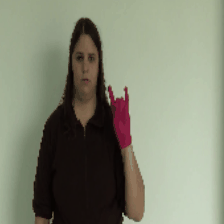

In [12]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [13]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)

# Most Recent < RUN This!!!>

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([64]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([64, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_2546233/2537940855.py:115: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer

  0%|          | 0/5760 [00:00<?, ?it/s]

{'loss': 16.5865, 'grad_norm': 30.59429931640625, 'learning_rate': 8.59375e-06, 'epoch': 0.02}
{'loss': 14.4931, 'grad_norm': 58.47425079345703, 'learning_rate': 1.71875e-05, 'epoch': 0.03}


2025-01-31 11:56:58,169 - INFO - Precision: 0.7968, Recall: 0.7617, F1: 0.7337, Accuracy: 0.7617


{'eval_loss': 2.1667022705078125, 'eval_accuracy': 0.76171875, 'eval_precision': 0.7967904491341992, 'eval_recall': 0.76171875, 'eval_f1': 0.7337064844877345, 'eval_runtime': 358.4399, 'eval_samples_per_second': 0.714, 'eval_steps_per_second': 0.357, 'epoch': 0.05}
{'loss': 10.1888, 'grad_norm': 56.96902084350586, 'learning_rate': 2.578125e-05, 'epoch': 1.0}
{'loss': 5.571, 'grad_norm': 40.733245849609375, 'learning_rate': 3.446180555555556e-05, 'epoch': 1.02}
{'loss': 2.5661, 'grad_norm': 22.693687438964844, 'learning_rate': 4.3142361111111114e-05, 'epoch': 1.04}


...

2025-01-31 18:03:14,706 - INFO - Precision: 1.0000, Recall: 1.0000, F1: 1.0000, Accuracy: 1.0000


{'eval_loss': 0.0006333552300930023, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_runtime': 370.0624, 'eval_samples_per_second': 0.692, 'eval_steps_per_second': 0.346, 'epoch': 6.05}
{'loss': 0.0019, 'grad_norm': 0.05547843500971794, 'learning_rate': 3.5329861111111114e-05, 'epoch': 7.01}
{'loss': 0.0019, 'grad_norm': 0.020581351593136787, 'learning_rate': 3.4365354938271605e-05, 'epoch': 7.03}
{'loss': 0.0022, 'grad_norm': 0.016313279047608376, 'learning_rate': 3.34008487654321e-05, 'epoch': 7.05}


2025-01-31 19:05:53,262 - INFO - Precision: 1.0000, Recall: 1.0000, F1: 1.0000, Accuracy: 1.0000


{'eval_loss': 0.0004577161744236946, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_runtime': 371.0878, 'eval_samples_per_second': 0.69, 'eval_steps_per_second': 0.345, 'epoch': 7.05}
{'train_runtime': 29576.2328, 'train_samples_per_second': 1.558, 'train_steps_per_second': 0.195, 'train_loss': 2.2551603910720184, 'epoch': 7.05}


2025-01-31 20:02:09,713 - INFO - Precision: 0.9948, Recall: 0.9939, F1: 0.9938, Accuracy: 0.9939
2025-01-31 20:02:09,716 - INFO - Training Metrics - Accuracy: 0.9939, Precision: 0.9948, Recall: 0.9939, F1: 0.9938


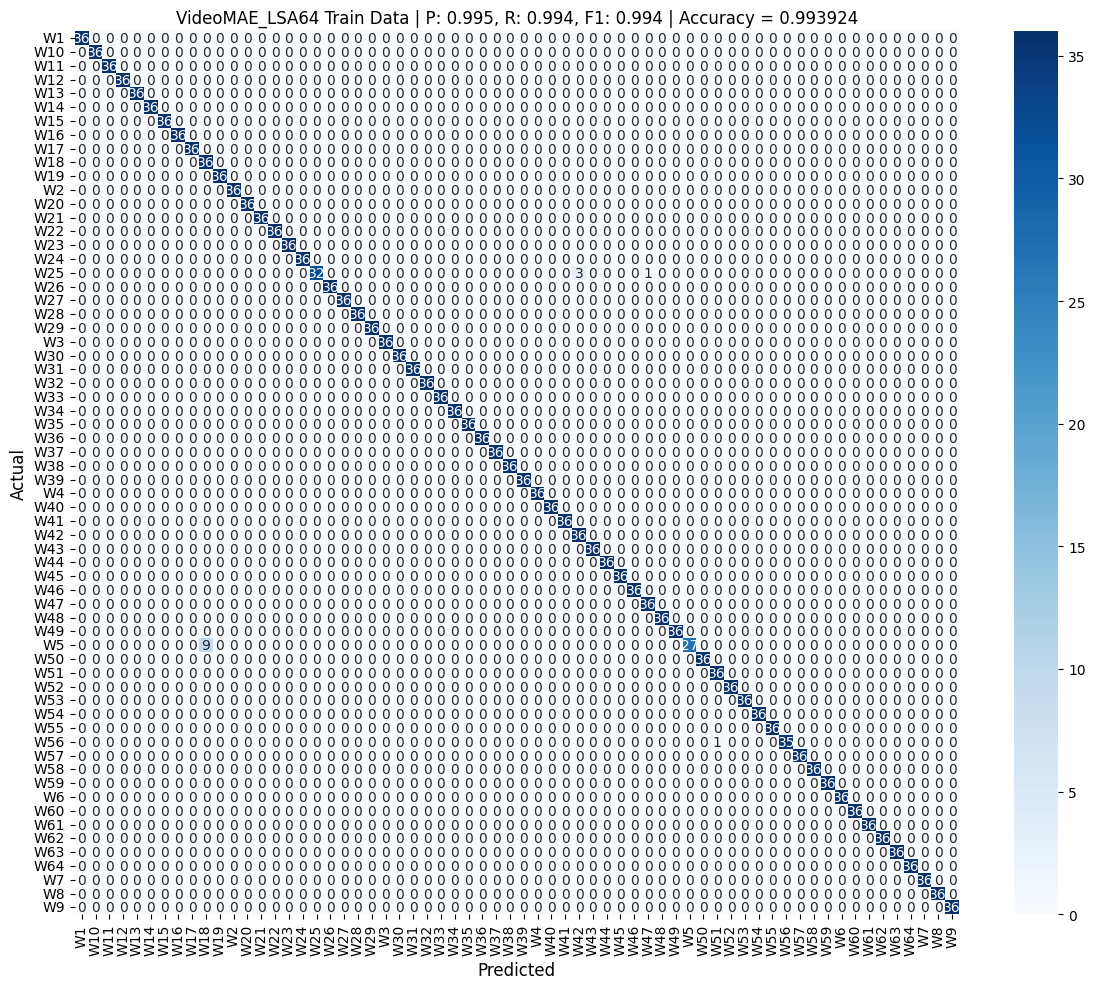

2025-01-31 20:08:17,648 - INFO - Precision: 1.0000, Recall: 1.0000, F1: 1.0000, Accuracy: 1.0000
2025-01-31 20:08:17,650 - INFO - Validation Metrics - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


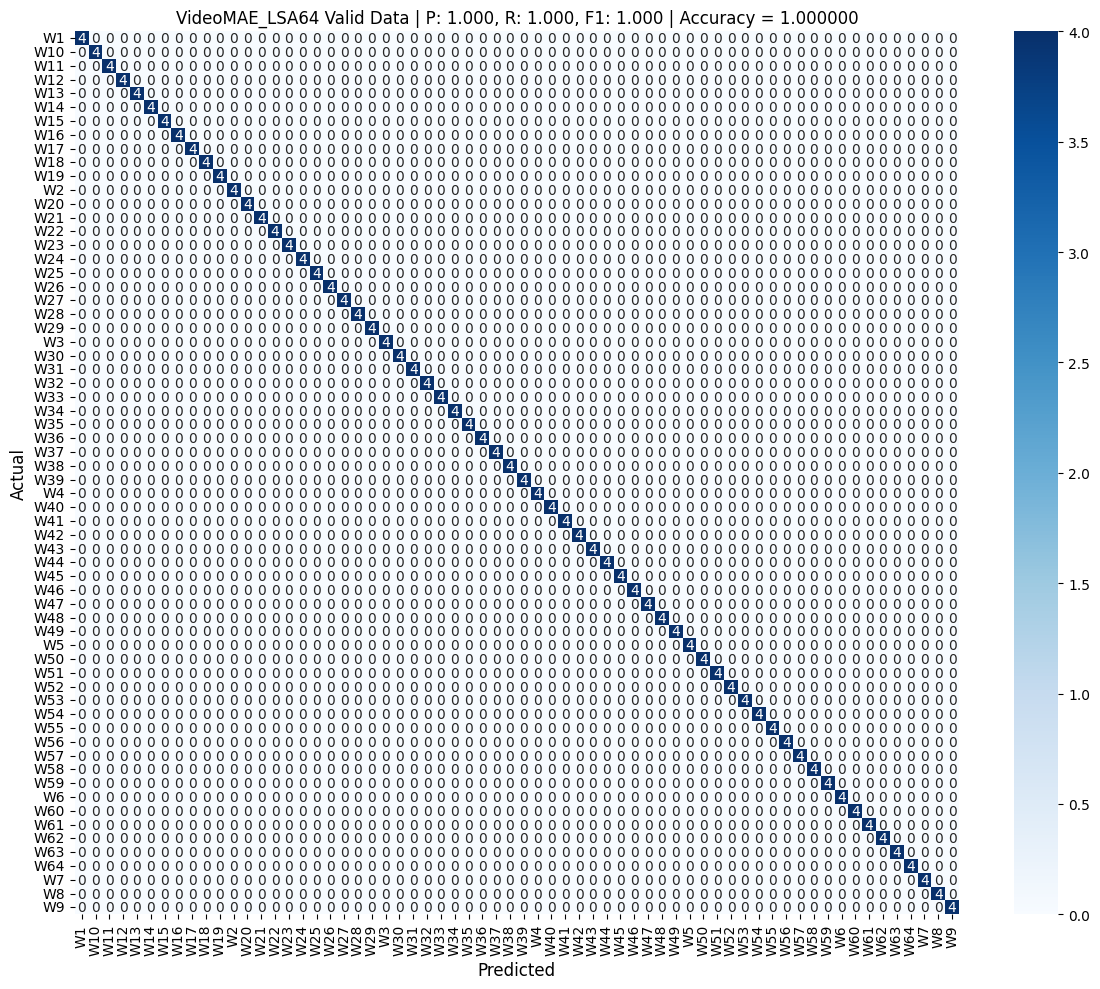

2025-01-31 20:25:01,274 - INFO - Precision: 0.9830, Recall: 0.9766, F1: 0.9755, Accuracy: 0.9766
2025-01-31 20:25:01,280 - INFO - Test Metrics - Accuracy: 0.9766, Precision: 0.9830, Recall: 0.9766, F1: 0.9755


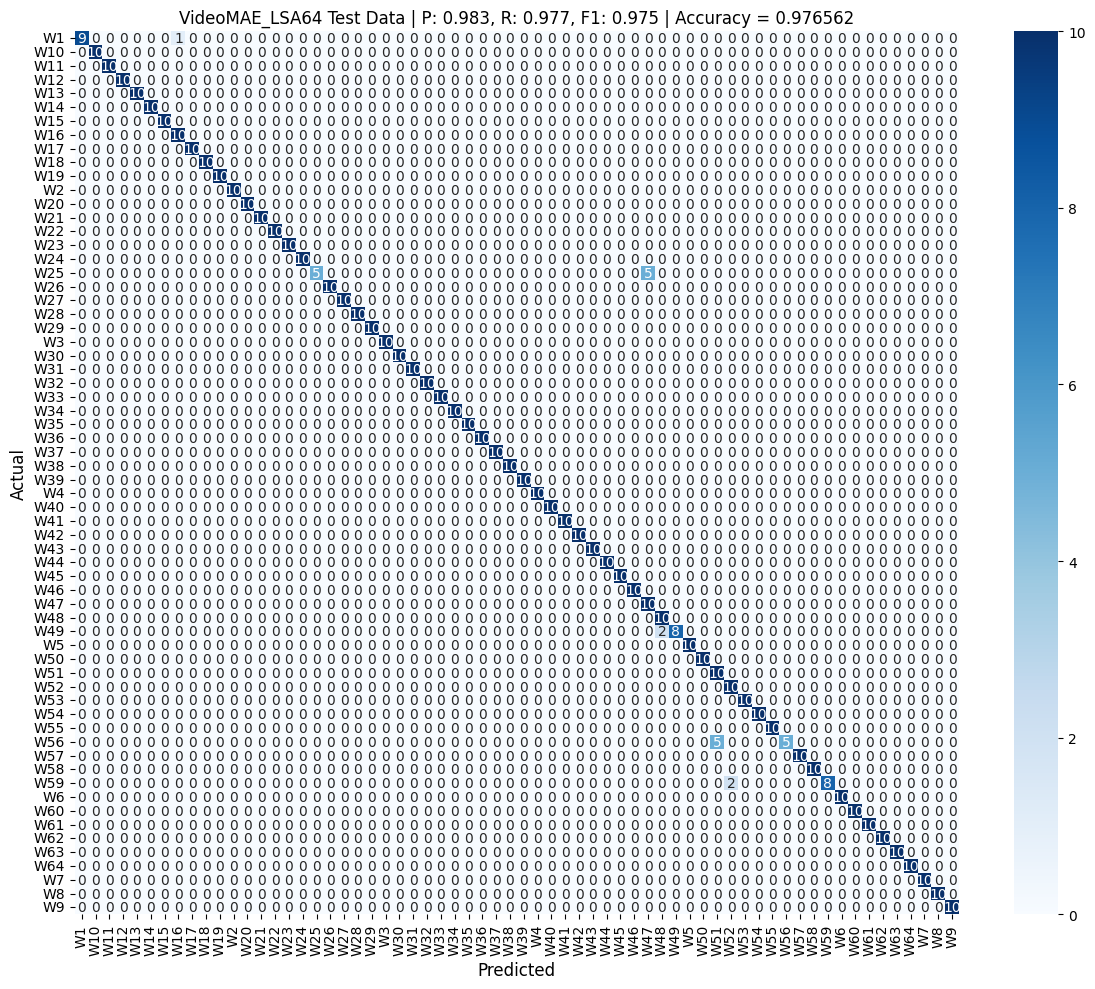

***** test metrics *****
  accuracy  = 0.9766
  f1        = 0.9755
  precision =  0.983
  recall    = 0.9766


2025-01-31 20:25:13,372 - INFO - Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_LSA64SR_8_kineticsFinetuned


Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_LSA64SR_8_kineticsFinetuned


In [17]:
import os
import torch
import logging
import matplotlib.pyplot as plt
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from transformers import EarlyStoppingCallback, AutoImageProcessor, VideoMAEForVideoClassification, VideoMAEImageProcessor
import seaborn as sns
import evaluate

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

num_epochs = 20

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and image processor
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
# model_ckpt="facebook/timesformer-base-finetuned-k400"
# image_processor = AutoImageProcessor.from_pretrained(model_ckpt)
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,
# )

# model_ckpt = "google/vivit-b-16x2-kinetics400"
# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")  
# model = VivitForVideoClassification.from_pretrained(
# model_ckpt,
# label2id=label2id,
# id2label=id2label,
# ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# ) 
model.to(device)

# Output directory for checkpoints
output_checkpoint_dir = r"/media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_LSA64SR_8_kineticsFinetuned"
os.makedirs(output_checkpoint_dir, exist_ok=True)

# Plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_labels, accuracy=None, dataset_name="Test Data", normalize=False, filename="confusion_matrix.png"):
    if normalize:
        conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    
    title = f"VideoMAE_LSA64 {dataset_name} | Accuracy = {accuracy:.6f}" if accuracy is not None else f"VideoMAE_LSA64| {dataset_name}"
    plt.title(title)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

# Compute metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    # Calculate metrics
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted',zero_division=0)
    # Log metrics
    logging.info(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Training arguments
#batch_size = 32
args = TrainingArguments(
    output_dir=output_checkpoint_dir,
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_ratio=0.1,
    logging_steps=100,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    load_best_model_at_end=True,
    max_steps=(train_dataset.num_videos // (2*4)) * num_epochs,  # Dynamically calculate max_steps
    report_to="none",
    fp16=True,
    weight_decay=0.01,
)

# Trainer initialization
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

# Train the model
trainer.train()
trainer.save_model()

# ------------------- TRAINING METRICS -------------------
train_predictions = trainer.predict(train_dataset)
train_preds = np.argmax(train_predictions.predictions, axis=1)
train_labels = train_predictions.label_ids

train_accuracy = accuracy_score(train_labels, train_preds)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(train_labels, train_preds, average='weighted')

logging.info(f"Training Metrics - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(train_labels, train_preds), 
    class_labels=list(id2label.values()), 
    accuracy=train_accuracy, 
    dataset_name=f"Train Data | P: {train_precision:.3f}, R: {train_recall:.3f}, F1: {train_f1:.3f}",
    filename="confusion_matrix_train1.png"
)

# ------------------- VALIDATION METRICS -------------------
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=1)
val_labels = val_predictions.label_ids

val_accuracy = accuracy_score(val_labels, val_preds)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

logging.info(f"Validation Metrics - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(val_labels, val_preds), 
    class_labels=list(id2label.values()), 
    accuracy=val_accuracy, 
    dataset_name=f"Valid Data | P: {val_precision:.3f}, R: {val_recall:.3f}, F1: {val_f1:.3f}",
    filename="confusion_matrix_valid1.png"
)

# ------------------- TEST METRICS -------------------
test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_labels = test_predictions.label_ids

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted')

logging.info(f"Test Metrics - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(test_labels, test_preds), 
    class_labels=list(id2label.values()), 
    accuracy=test_accuracy, 
    dataset_name=f"Test Data | P: {test_precision:.3f}, R: {test_recall:.3f}, F1: {test_f1:.3f}",
    filename="confusion_matrix_test1.png"
)

# Calculate metrics for the test dataset
test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
}

# Log and save metrics
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
trainer.save_state()
trainer.push_to_hub()

logging.info(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
print(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
